In [7]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time

In [12]:

data = []

for page in range(1, 6):

    # Page 1 has different URL
    if page == 1:
        url = "http://books.toscrape.com/"
    else:
        url = f"http://books.toscrape.com/catalogue/page-{page}.html"

    response = requests.get(url)
    soup = BeautifulSoup(response.text, "html.parser")

    books = soup.find_all("article", class_="product_pod")

    for book in books:
        title = book.h3.a["title"]
        price = book.find("p", class_="price_color").text
        rating = book.find("p", class_="star-rating")["class"][1]
        availability = book.find("p", class_="instock availability").text.strip()

        data.append([title, price, rating, availability])

    time.sleep(1)

# Create DataFrame
df = pd.DataFrame(data, columns=["Title", "Price", "Rating", "Availability"])

# Clean Price Column (Handles Encoding Issue)
df["Price"] = (
    df["Price"]
    .str.replace("Â£", "", regex=False)   # remove encoded symbol
    .str.replace("£", "", regex=False)    # remove normal symbol
    .str.strip()
)

df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

print(df.head())
print(df["Price"].head())
print(df.dtypes)

                                   Title  Price Rating Availability
0                   A Light in the Attic  51.77  Three     In stock
1                     Tipping the Velvet  53.74    One     In stock
2                             Soumission  50.10    One     In stock
3                          Sharp Objects  47.82   Four     In stock
4  Sapiens: A Brief History of Humankind  54.23   Five     In stock
0    51.77
1    53.74
2    50.10
3    47.82
4    54.23
Name: Price, dtype: float64
Title            object
Price           float64
Rating           object
Availability     object
dtype: object


In [13]:
# Basic Insights
print("Average Book Price:", round(df["Price"].mean(), 2))
print("\nHighest Price:", df["Price"].max())
print("Lowest Price:", df["Price"].min())

print("\nRating Distribution:")
print(df["Rating"].value_counts())

Average Book Price: 34.56

Highest Price: 58.11
Lowest Price: 10.16

Rating Distribution:
Rating
Three    22
One      22
Five     19
Two      19
Four     18
Name: count, dtype: int64


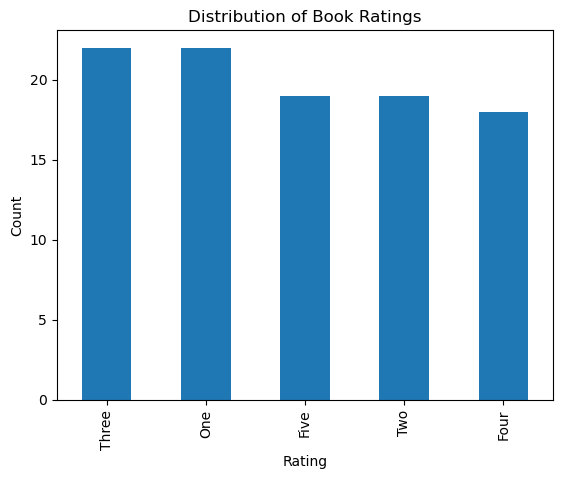

In [14]:
import matplotlib.pyplot as plt

df["Rating"].value_counts().plot(kind="bar")
plt.title("Distribution of Book Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()